# Results overview

This notebook provides a quick overview of the current evaluation data in `results/eval_results.csv`.

It focuses on:

- run inventory and metadata,
- aggregate success/return metrics,
- comparison of experiment groups (for example OPD normalization variants).

In [18]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "visualization" else Path.cwd().resolve()
CSV_PATH = REPO_ROOT / "results" / "eval_results.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Run notebook from repo root or visualization/.")

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Columns: {len(df.columns)}")

df.head(3)

Loaded 12 rows from /Users/antoniomari/vla-continual-learning/results/eval_results.csv
Columns: 38


,checkpoint_location,episode_len,eval_rollout_epoch,experiment_name,global_batch_size,global_step,group_size,hydra_config_name,lora_path,num_group_envs,return,reward,rollout_epoch,seed,success_at_end,success_once,task_0_success,task_0_success_total,task_1_success,task_1_success_total,task_2_success,task_2_success_total,task_3_success,task_3_success_total,task_4_success,task_4_success_total,task_5_success,task_5_success_total,task_6_success,task_6_success_total,task_7_success,task_7_success_total,task_8_success,task_8_success_total,task_9_success,task_9_success_total,temperature_eval,timestamp_utc
0,logs_spatial/sequential/task_4_seed186,512.0,10,eval_opd_task_4_seed186_spatial_step_50,8192,50,8,libero_spatial_grpo_openvlaoft_eval_spatial,/users/anmari/vla-continual-learning/logs_spat...,1,0.009375,0.000018,4,186,0.001875,0.019583,0.012821,312.0,0.00641,312.0,0.025641,312.0,0.019231,312.0,0.025641,312.0,0.00641,312.0,0.019231,312.0,0.022436,312.0,0.016026,312.0,0.0,312.0,1.6,2026-04-25T08:30:10Z
1,logs_spatial/sequential/task_4_seed185,512.0,10,eval_opd_task_4_seed185_spatial_step_50,8192,50,8,libero_spatial_grpo_openvlaoft_eval_spatial,/users/anmari/vla-continual-learning/logs_spat...,1,0.093750,0.000183,4,185,0.018750,0.221250,0.362500,80.0,0.00000,80.0,0.575000,80.0,0.387500,80.0,0.062500,80.0,0.00000,80.0,0.800000,80.0,0.025000,80.0,0.000000,80.0,0.0,80.0,1.6,2026-04-26T00:31:32Z
2,logs_spatial/sequential/task_1_seed185,512.0,10,eval_opd_task_1_seed185_spatial_step_50,8192,50,8,libero_spatial_grpo_openvlaoft_eval_spatial,/users/anmari/vla-continual-learning/logs_spat...,1,0.281250,0.000549,4,185,0.056250,0.315000,0.575000,80.0,0.46250,80.0,0.700000,80.0,0.675000,80.0,0.087500,80.0,0.03750,80.0,0.450000,80.0,0.162500,80.0,0.000000,80.0,0.0,80.0,1.6,2026-04-26T00:31:54Z


In [19]:
# Basic inventory
summary = {
    "rows": len(df),
    "unique_experiments": df["experiment_name"].nunique() if "experiment_name" in df else None,
    "unique_seeds": df["seed"].nunique() if "seed" in df else None,
    "global_steps": sorted(df["global_step"].dropna().unique().tolist()) if "global_step" in df else None,
    "configs": sorted(df["hydra_config_name"].dropna().unique().tolist()) if "hydra_config_name" in df else None,
}
summary

{'rows': 12,
 'unique_experiments': 11,
 'unique_seeds': 6,
 'global_steps': [0, 50],
 'configs': ['libero_spatial_grpo_openvlaoft_eval_spatial']}

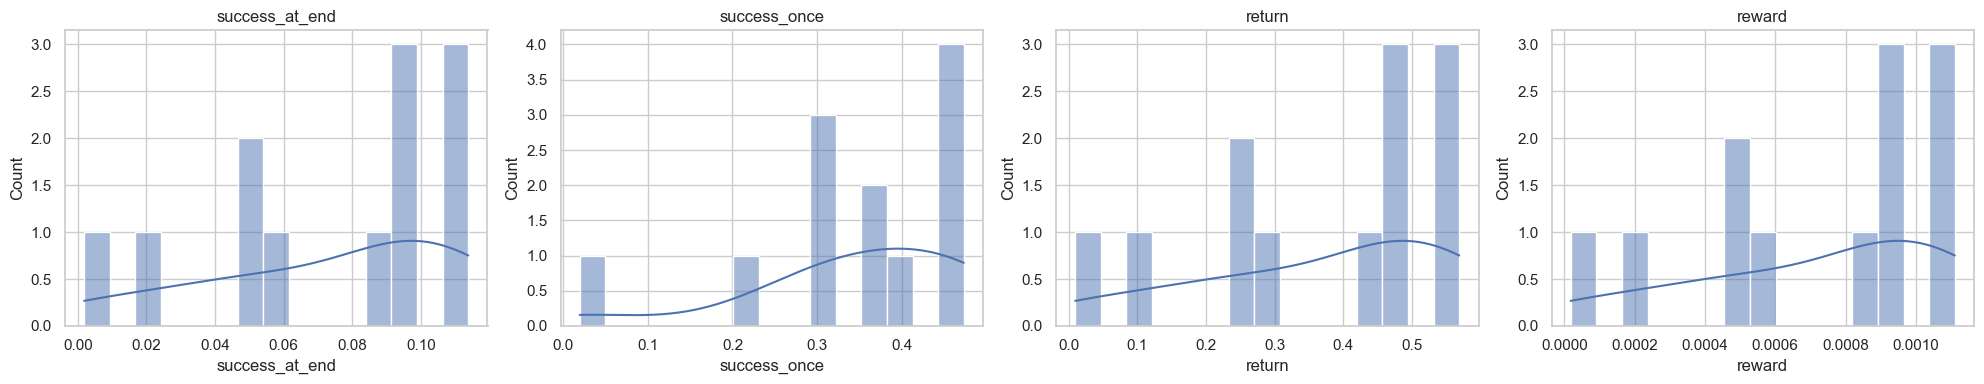

In [20]:
# Core metric distributions
metrics = [m for m in ["success_at_end", "success_once", "return", "reward"] if m in df.columns]
if not metrics:
    raise ValueError("No expected metrics found in CSV")

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    sns.histplot(df[metric].dropna(), bins=15, kde=True, ax=ax)
    ax.set_title(metric)

plt.tight_layout()
plt.show()

/var/folders/tl/9w8ls2bx3d53r9hw119zzxmh0000gn/T/ipykernel_29698/4170911602.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


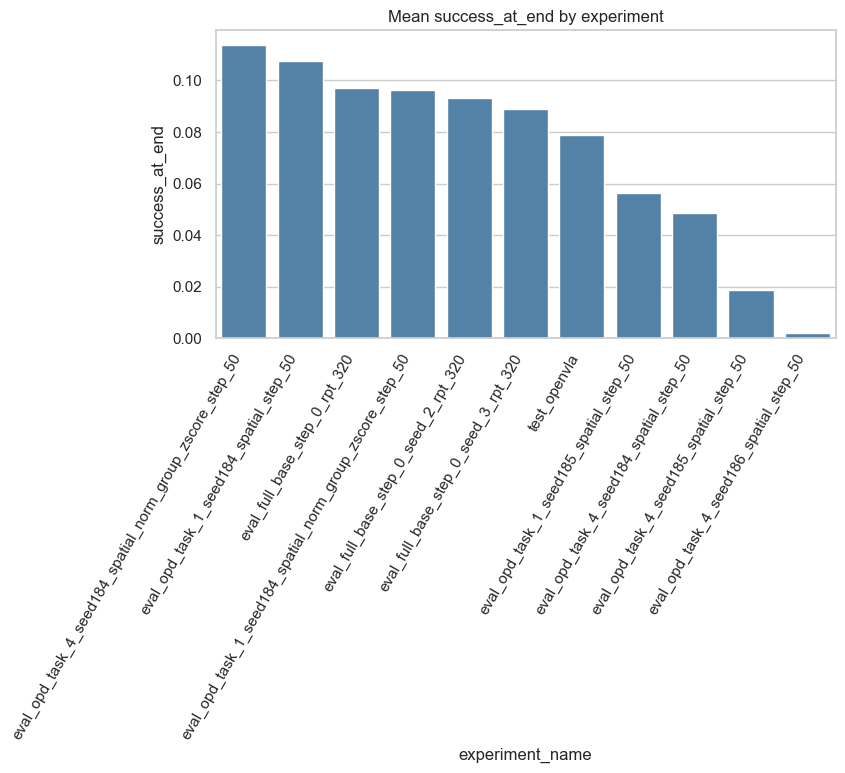

In [21]:
# Compare runs by experiment name (success_at_end)
if "experiment_name" in df.columns and "success_at_end" in df.columns:
    ordered = (
        df.groupby("experiment_name", as_index=False)["success_at_end"]
        .mean()
        .sort_values("success_at_end", ascending=False)
    )

    plt.figure(figsize=(max(8, 0.5 * len(ordered)), 4))
    sns.barplot(data=ordered, x="experiment_name", y="success_at_end", color="steelblue")
    plt.xticks(rotation=60, ha="right")
    plt.title("Mean success_at_end by experiment")
    plt.tight_layout()
    plt.show()

    ordered.head(10)
else:
    print("Required columns missing: experiment_name or success_at_end")

In [22]:
# Download ALL W&B logs/files from remote to local disk
# - Set WANDB_ENTITY (or ENTITY below)
# - Keep RUN_DOWNLOAD=False to preview
# - Set RUN_DOWNLOAD=True to execute downloads
from pathlib import Path
import json
import os

import wandb

RUN_DOWNLOAD = True
SKIP_ALREADY_DOWNLOADED = True            # True => do not redownload runs that already exist locally
ENTITY = os.getenv("WANDB_ENTITY", "")  # e.g. "my-team"
ONLY_RESULTS_EXPERIMENTS = False          # True => restrict to run.name in eval_results.csv experiment_name
OUT_DIR = REPO_ROOT / "results" / "wandb_downloads"

config_search_roots = [
    REPO_ROOT / "examples" / "embodiment" / "config" / "crl_experiment",
    REPO_ROOT / "examples" / "embodiment" / "config" / "examples",
    REPO_ROOT / "examples" / "embodiment" / "config",
]

# Infer project names from hydra config files used in eval_results.csv
inferred_projects = set()
if "hydra_config_name" in df.columns:
    hydra_names = sorted(df["hydra_config_name"].dropna().astype(str).unique())
    for name in hydra_names:
        config_file = None
        for root in config_search_roots:
            cand = root / f"{name}.yaml"
            if cand.exists():
                config_file = cand
                break
        if config_file is None:
            continue

        text = config_file.read_text(encoding="utf-8")
        for line in text.splitlines():
            stripped = line.strip()
            if stripped.startswith("project_name:"):
                inferred_projects.add(stripped.split(":", 1)[1].strip().strip('"'))

projects = sorted(inferred_projects)
if not projects:
    raise ValueError("Could not infer W&B project_name from experiment configs")

wanted_run_names = set(df["experiment_name"].dropna().astype(str).unique()) if "experiment_name" in df.columns else set()

OUT_DIR.mkdir(parents=True, exist_ok=True)
api = wandb.Api()

# Auto-detect entity from current W&B login if not explicitly provided.
if not ENTITY:
    ENTITY = getattr(api, "default_entity", None) or ""
if not ENTITY:
    try:
        viewer = api.viewer
        if isinstance(viewer, dict):
            ENTITY = viewer.get("entity") or viewer.get("username") or ""
    except Exception:
        pass
if not ENTITY:
    raise ValueError("Could not determine W&B entity. Set WANDB_ENTITY env var or ENTITY in this cell.")

print(f"Entity: {ENTITY}")
print(f"Projects: {projects}")
print(f"Output directory: {OUT_DIR}")

run_rows = []
for project in projects:
    runs = api.runs(f"{ENTITY}/{project}")
    for run in runs:
        if ONLY_RESULTS_EXPERIMENTS and wanted_run_names and run.name not in wanted_run_names:
            continue
        run_rows.append(
            {
                "entity": ENTITY,
                "project": project,
                "run_id": run.id,
                "run_name": run.name,
                "state": run.state,
                "url": run.url,
            }
        )

runs_df = pd.DataFrame(run_rows)
print(f"Matched {len(runs_df)} remote runs")
display(runs_df.head(20) if len(runs_df) else runs_df)

if RUN_DOWNLOAD and len(runs_df):
    download_rows = []
    skipped_rows = []

    for row in run_rows:
        run_dir = OUT_DIR / row["project"] / f"{row['run_name']}__{row['run_id']}"
        meta_path = run_dir / "run_meta.json"
        history_path = run_dir / "history.jsonl"

        # Skip already-downloaded runs when requested.
        # We consider a run downloaded if metadata and history exist.
        if SKIP_ALREADY_DOWNLOADED and meta_path.exists() and history_path.exists():
            skipped_rows.append(
                {
                    "run": f"{row['project']}/{row['run_id']}",
                    "reason": "already_downloaded",
                    "local_dir": str(run_dir),
                }
            )
            continue

        run = api.run(f"{row['entity']}/{row['project']}/{row['run_id']}")
        run_dir.mkdir(parents=True, exist_ok=True)

        # Save metadata
        meta_path.write_text(
            json.dumps(
                {
                    "entity": row["entity"],
                    "project": row["project"],
                    "run_id": row["run_id"],
                    "run_name": row["run_name"],
                    "state": row["state"],
                    "url": row["url"],
                    "config": dict(run.config),
                    "summary": dict(run.summary),
                },
                indent=2,
                default=str,
            ),
            encoding="utf-8",
        )

        # Download all files attached to this run
        file_count = 0
        for f in run.files():
            f.download(root=str(run_dir), replace=True)
            file_count += 1

        # Save full metric history
        with history_path.open("w", encoding="utf-8") as hf:
            for item in run.scan_history():
                hf.write(json.dumps(item, default=str) + "\n")

        download_rows.append(
            {
                "run": f"{row['project']}/{row['run_id']}",
                "files_downloaded": file_count,
                "local_dir": str(run_dir),
            }
        )

    print(f"Downloaded {len(download_rows)} runs; skipped {len(skipped_rows)} existing runs")
    display(pd.DataFrame(download_rows))
    if skipped_rows:
        display(pd.DataFrame(skipped_rows).head(20))
else:
    print("Preview mode only. Set RUN_DOWNLOAD=True to download all remote logs/files.")

Entity: anmari-epfl
Projects: ['rlinf']
Output directory: /Users/antoniomari/vla-continual-learning/results/wandb_downloads
Matched 177 remote runs


,entity,project,run_id,run_name,state,url
0,anmari-epfl,rlinf,lgw42uoq,task_0_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/lgw42uoq
1,anmari-epfl,rlinf,etqj9jll,task_1_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/etqj9jll
2,anmari-epfl,rlinf,drr352dk,test_openvla,finished,https://wandb.ai/anmari-epfl/rlinf/runs/drr352dk
3,anmari-epfl,rlinf,jrr1edo1,task_0_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/jrr1edo1
4,anmari-epfl,rlinf,nxhq3obt,task_0_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/nxhq3obt
5,anmari-epfl,rlinf,h3ll9bsg,task_0_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/h3ll9bsg
6,anmari-epfl,rlinf,vta7dbuv,test_openvla,finished,https://wandb.ai/anmari-epfl/rlinf/runs/vta7dbuv
7,anmari-epfl,rlinf,gr2uucyd,task_1_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/gr2uucyd
8,anmari-epfl,rlinf,3n4wpfed,test_openvla,finished,https://wandb.ai/anmari-epfl/rlinf/runs/3n4wpfed
9,anmari-epfl,rlinf,oqd1102h,task_0_seed1234_spatial,finished,https://wandb.ai/anmari-epfl/rlinf/runs/oqd1102h


Downloaded 0 runs; skipped 177 existing runs


""


,run,reason,local_dir
0,rlinf/lgw42uoq,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
1,rlinf/etqj9jll,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
2,rlinf/drr352dk,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
3,rlinf/jrr1edo1,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
4,rlinf/nxhq3obt,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
5,rlinf/h3ll9bsg,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
6,rlinf/vta7dbuv,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
7,rlinf/gr2uucyd,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
8,rlinf/3n4wpfed,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...
9,rlinf/oqd1102h,already_downloaded,/Users/antoniomari/vla-continual-learning/resu...


In [23]:
# Build experiment summary from downloaded W&B run folders (run_meta.json + output.log)
import ast
import re

WDB_ROOT = REPO_ROOT / "results" / "wandb_downloads"
SUMMARY_CSV = REPO_ROOT / "results" / "wandb_experiment_summary_from_logs.csv"


pd.set_option("display.max_columns", None)


ansi_re = re.compile(r"\x1B\[[0-9;]*[A-Za-z]")

def _clean_ansi(text: str) -> str:
    return ansi_re.sub("", text)

def _extract_last_eval_metrics_from_output_log(log_path: Path):
    if not log_path.exists():
        return None

    text = log_path.read_text(encoding="utf-8", errors="ignore")
    text = _clean_ansi(text)
    last = None
    for line in text.splitlines():
        if "eval_metrics=" not in line:
            continue
        payload = line.split("eval_metrics=", 1)[1].strip()
        try:
            obj = ast.literal_eval(payload)
            if isinstance(obj, dict):
                last = obj
        except Exception:
            continue
    return last

def _metric(metrics: dict, name: str):
    if not isinstance(metrics, dict):
        return None
    if name in metrics:
        return metrics.get(name)
    return metrics.get(f"eval/env_info/{name}")

def _extract_training_task(run_name: str):
    if not run_name:
        return None
    m = re.search(r"task_(\d+)", run_name)
    return int(m.group(1)) if m else None

# Seed annotations from comments in examples/crl_experiment/jobs/embodiment_slurm_opd_sweep.sh
SEED_COMMENT_MAP = {
    256: {"comment_tag": "legacy_hp", "teacher_type_comment": None, "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "batch size 32"},
    255: {"comment_tag": "legacy_hp", "teacher_type_comment": None, "teacher_lr_comment": "2e-05", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "batch size 256"},
    254: {"comment_tag": "legacy_hp", "teacher_type_comment": None, "teacher_lr_comment": "2e-06", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "batch size 32"},
    253: {"comment_tag": "legacy_hp", "teacher_type_comment": None, "teacher_lr_comment": "2e-05", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "mirrored data, batch size 32"},
    252: {"comment_tag": "legacy_hp", "teacher_type_comment": None, "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "mirrored data, batch size 32"},
    251: {"comment_tag": "single_task_hp", "teacher_type_comment": None, "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "single task, batch size 32"},
    250: {"comment_tag": "single_task_hp", "teacher_type_comment": None, "teacher_lr_comment": "2e-05", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "single task, batch size 32"},
    230: {"comment_tag": "single_task_hp", "teacher_type_comment": None, "teacher_lr_comment": "2e-04", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "single task, batch size 32"},
    229: {"comment_tag": "single_task_hp", "teacher_type_comment": None, "teacher_lr_comment": "1e-03", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "single task, batch size 32"},
    200: {"comment_tag": "opd_variant", "teacher_type_comment": "fixed preprocessing", "teacher_lr_comment": "2e-05", "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "fixed preprocessing, batch size 32"},
    199: {"comment_tag": "opd_variant", "teacher_type_comment": "teacher fixed", "teacher_lr_comment": None, "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "looks like teacher was fixed"},
    198: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": "GRPO-style OPD loss", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": None},
    197: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "2e-05", "student_train_steps_comment": None, "objective_comment": "GRPO-style OPD loss", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": None},
    196: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "2e-05", "student_train_steps_comment": 10, "objective_comment": "GRPO-style OPD loss", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": None},
    195: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 10, "objective_comment": "GRPO-style OPD loss", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": None},
    194: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher after fixing", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "OPD", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "after fixing"},
    193: {"comment_tag": "opd_variant", "teacher_type_comment": None, "teacher_lr_comment": None, "student_train_steps_comment": None, "objective_comment": None, "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "after restoring files"},
    192: {"comment_tag": "opd_variant", "teacher_type_comment": "SFT teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 20, "objective_comment": "OPD", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "teacher 1000 training steps"},
    191: {"comment_tag": "opd_variant", "teacher_type_comment": "SFT teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "OPD", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": "teacher 1000 training steps"},
    190: {"comment_tag": "opd_variant", "teacher_type_comment": "SFT teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "OPD", "adv_norm_comment": "with advantage normalization", "rollouts_per_step_comment": None, "data_note_comment": "same as seed 191"},
    189: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "REINFORCE-style OPD objective (no ratio clipping)", "adv_norm_comment": None, "rollouts_per_step_comment": None, "data_note_comment": None},
    188: {"comment_tag": "opd_variant", "teacher_type_comment": "OPD teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "REINFORCE-style OPD objective (no ratio clipping)", "adv_norm_comment": "no advantage normalization", "rollouts_per_step_comment": None, "data_note_comment": "same as seed 189"},
    187: {"comment_tag": "opd_variant", "teacher_type_comment": "RL teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "REINFORCE-style OPD objective (no ratio clipping)", "adv_norm_comment": "no advantage normalization", "rollouts_per_step_comment": None, "data_note_comment": "same as seed 188 but RL teacher"},
    186: {"comment_tag": "opd_variant", "teacher_type_comment": "RL teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": 50, "objective_comment": "REINFORCE-style OPD objective (no ratio clipping)", "adv_norm_comment": "no advantage normalization", "rollouts_per_step_comment": 128, "data_note_comment": "same as seed 187"},
    185: {"comment_tag": "opd_variant", "teacher_type_comment": "SFT teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": "OPD", "adv_norm_comment": None, "rollouts_per_step_comment": 128, "data_note_comment": "teacher 1000 steps"},
    184: {"comment_tag": "opd_variant", "teacher_type_comment": "SFT teacher", "teacher_lr_comment": "1e-04", "student_train_steps_comment": None, "objective_comment": "OPD", "adv_norm_comment": "with advantage normalization", "rollouts_per_step_comment": 128, "data_note_comment": "same as seed 185; tried mad_abs and batch_zscore"},
}

def _seed_comment_hparams(seed_value):
    try:
        key = int(seed_value) if seed_value is not None else None
    except Exception:
        key = None
    if key is None:
        return {}
    return dict(SEED_COMMENT_MAP.get(key, {}))

def _extract_train_steps(run_name: str, lora_path: str, seed_comment_meta: dict):
    # Prefer explicit checkpoint/run naming first.
    if run_name:
        m = re.search(r"step_(\d+)", run_name)
        if m:
            return int(m.group(1))
        m = re.search(r"_(\d+)_steps", run_name)
        if m:
            return int(m.group(1))

    if lora_path:
        m = re.search(r"global_step_(\d+)", str(lora_path))
        if m:
            return int(m.group(1))

    # Fall back to comment-derived student steps if available.
    v = seed_comment_meta.get("student_train_steps_comment") if seed_comment_meta else None
    return int(v) if v is not None else None

rows = []
run_meta_files = sorted(WDB_ROOT.glob("*/*/run_meta.json"))

for meta_path in run_meta_files:
    run_dir = meta_path.parent
    log_path = run_dir / "output.log"

    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    cfg = meta.get("config", {}) or {}
    summary = meta.get("summary", {}) or {}

    final_metrics = _extract_last_eval_metrics_from_output_log(log_path)
    has_final_output = isinstance(final_metrics, dict) and len(final_metrics) > 0

    # Prefer explicit final metrics from output.log when present.
    metrics_source = final_metrics if has_final_output else summary

    task_values = {}
    for i in range(10):
        task_values[f"task_{i}_success"] = _metric(metrics_source, f"task_{i}_success")
        task_values[f"task_{i}_success_total"] = _metric(metrics_source, f"task_{i}_success_total")

    # Actual eval episode count per task from aggregated metrics (already accounts for all GPUs + eval epochs).
    eval_episode_candidates = [
        task_values.get(f"task_{i}_success_total")
        for i in range(10)
        if task_values.get(f"task_{i}_success_total") is not None
    ]
    eval_episodes_per_task = eval_episode_candidates[0] if eval_episode_candidates else None

    run_name = meta.get("run_name")
    seed_value = (((cfg.get("actor") or {}).get("seed")))
    seed_comment_meta = _seed_comment_hparams(seed_value)
    lora_path_value = ((((cfg.get("actor") or {}).get("model") or {}).get("lora_path")))
    train_steps_used = _extract_train_steps(run_name, lora_path_value, seed_comment_meta)

    row = {
        "project": meta.get("project"),
        "entity": meta.get("entity"),
        "run_id": meta.get("run_id"),
        "run_name": run_name,
        "training_task": _extract_training_task(run_name),
        "method": "OPD" if (run_name and "opd" in run_name.lower()) else "GRPO",
        "state": meta.get("state"),
        "status": "complete" if has_final_output else "incomplete",
        "result_source": "output.log" if has_final_output else "run_meta.summary (fallback)",
        "run_url": meta.get("url"),
        "run_dir": str(run_dir),
        "has_output_log": log_path.exists(),
        "seed": seed_value,
        "global_batch_size": (((cfg.get("actor") or {}).get("global_batch_size"))),
        "train_steps_used": train_steps_used,
        "micro_batch_size": (((cfg.get("actor") or {}).get("micro_batch_size"))),
        "lr": ((((cfg.get("actor") or {}).get("optim") or {}).get("lr"))),
        "temperature_eval": ((((cfg.get("algorithm") or {}).get("sampling_params") or {}).get("temperature_eval"))),
        "rollout_epoch": (((cfg.get("algorithm") or {}).get("rollout_epoch"))),
        "num_env_eval": ((((cfg.get("env") or {}).get("eval") or {}).get("num_envs"))),
        "eval_rollout_epoch": (((cfg.get("algorithm") or {}).get("eval_rollout_epoch"))),
        "eval_episodes_per_task": eval_episodes_per_task,
        "lora_path": lora_path_value,
        "log_path": ((((cfg.get("runner") or {}).get("logger") or {}).get("log_path"))),
        "return": _metric(metrics_source, "return"),
        "reward": _metric(metrics_source, "reward"),
        "episode_len": _metric(metrics_source, "episode_len"),
        "success_once": _metric(metrics_source, "success_once"),
        "success_at_end": _metric(metrics_source, "success_at_end"),
    }
    row.update(task_values)
    row.update(seed_comment_meta)

    # Helpful aggregates
    trn_vals = [task_values[f"task_{i}_success"] for i in range(5) if task_values[f"task_{i}_success"] is not None]
    hld_vals = [task_values[f"task_{i}_success"] for i in range(5, 10) if task_values[f"task_{i}_success"] is not None]
    row["trn_avg"] = sum(trn_vals) / len(trn_vals) if trn_vals else None
    row["hld_avg"] = sum(hld_vals) / len(hld_vals) if hld_vals else None

    rows.append(row)

summary_df = pd.DataFrame(rows)
if not summary_df.empty:
    allowed_seed_comments = {184, 185, 186}  # keep only selected OPD seeds for now

    is_complete = summary_df["status"].eq("complete")
    is_grpo = summary_df["method"].eq("GRPO")
    is_opd = summary_df["method"].eq("OPD")
    is_opd_seed_allowed = summary_df["seed"].isin(allowed_seed_comments)

    summary_df = summary_df[
        is_complete
        & (is_grpo | (is_opd & is_opd_seed_allowed))
    ].copy()

    summary_df = summary_df.sort_values(["method", "seed", "run_name"], ascending=[True, True, True])

SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(SUMMARY_CSV, index=False)

print(f"Parsed {len(summary_df)} complete runs (all GRPO + OPD seeds 184/185/186) from {WDB_ROOT}")
print(f"Saved: {SUMMARY_CSV}")
# if not summary_df.empty:
    # print(summary_df["status"].value_counts(dropna=False).to_string())
print(len(summary_df))

Parsed 28 complete runs (all GRPO + OPD seeds 184/185/186) from /Users/antoniomari/vla-continual-learning/results/wandb_downloads
Saved: /Users/antoniomari/vla-continual-learning/results/wandb_experiment_summary_from_logs.csv
28


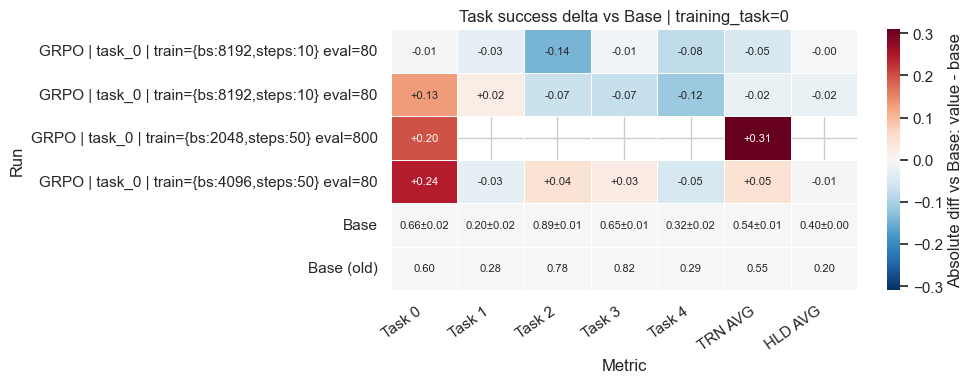

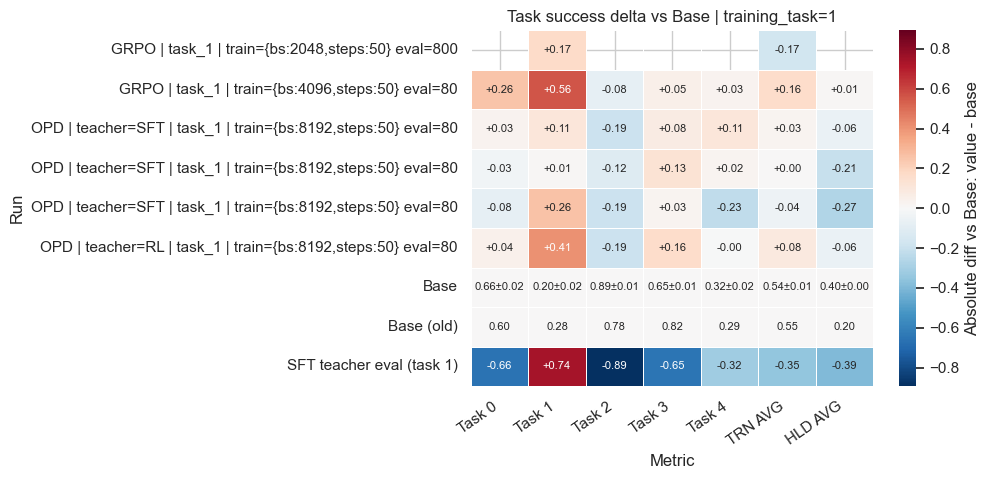

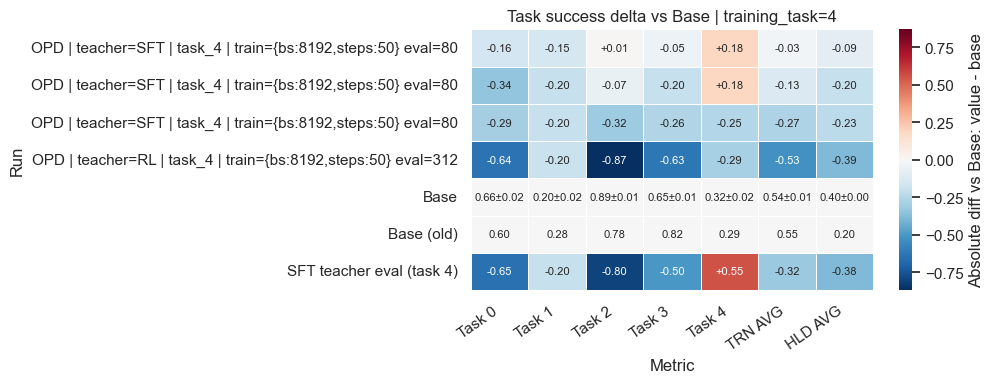


===== task_0 =====


Model,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
Base (old),0.600,0.275,0.775,0.825,0.287,0.552,0.198
Base,0.656±0.022,0.202±0.017,0.893±0.011,0.649±0.005,0.316±0.016,0.543±0.008,0.398±0.003
"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.650,0.175,0.750,0.637,0.237,0.490,0.395
"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.787,0.225,0.825,0.575,0.200,0.522,0.378
"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.650,0.175,0.750,0.637,0.237,0.490,0.395
"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.787,0.225,0.825,0.575,0.200,0.522,0.378
"GRPO | task_0 | train={bs:2048,steps:50} eval=800",0.853,nan,nan,nan,nan,0.853,nan
"GRPO | task_0 | train={bs:4096,steps:50} eval=80",0.900,0.175,0.938,0.675,0.263,0.590,0.393



===== task_1 =====


Model,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
Base (old),0.600,0.275,0.775,0.825,0.287,0.552,0.198
Base,0.656±0.022,0.202±0.017,0.893±0.011,0.649±0.005,0.316±0.016,0.543±0.008,0.398±0.003
SFT teacher eval (task 1),0.000,0.947,0.000,0.000,0.000,0.189,0.004
"GRPO | task_1 | train={bs:2048,steps:50} eval=800",nan,0.370,nan,nan,nan,0.370,nan
"GRPO | task_1 | train={bs:4096,steps:50} eval=80",0.912,0.762,0.812,0.700,0.350,0.708,0.407
"OPD | teacher=SFT | task_1 | train={bs:8192,steps:50} eval=80",0.688,0.312,0.700,0.725,0.425,0.570,0.340
"OPD | teacher=SFT | task_1 | train={bs:8192,steps:50} eval=80",0.625,0.212,0.775,0.775,0.338,0.545,0.193
"OPD | teacher=SFT | task_1 | train={bs:8192,steps:50} eval=80",0.575,0.463,0.700,0.675,0.087,0.500,0.130
"OPD | teacher=SFT | task_1 | train={bs:8192,steps:50} eval=80",0.688,0.312,0.700,0.725,0.425,0.570,0.340
"OPD | teacher=SFT | task_1 | train={bs:8192,steps:50} eval=80",0.625,0.212,0.775,0.775,0.338,0.545,0.193



===== task_4 =====


Model,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
Base (old),0.600,0.275,0.775,0.825,0.287,0.552,0.198
Base,0.656±0.022,0.202±0.017,0.893±0.011,0.649±0.005,0.316±0.016,0.543±0.008,0.398±0.003
SFT teacher eval (task 4),0.006,0.000,0.091,0.147,0.869,0.223,0.018
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.500,0.050,0.900,0.600,0.500,0.510,0.310
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.312,0.000,0.825,0.450,0.500,0.417,0.198
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.362,0.000,0.575,0.388,0.062,0.278,0.165
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.500,0.050,0.900,0.600,0.500,0.510,0.310
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.312,0.000,0.825,0.450,0.500,0.417,0.198
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.362,0.000,0.575,0.388,0.062,0.278,0.165
"OPD | teacher=SFT | task_4 | train={bs:8192,steps:50} eval=80",0.500,0.050,0.900,0.600,0.500,0.510,0.310



===== task_0 (copy-friendly) =====
                                            Model      Task 0      Task 1      Task 2      Task 3      Task 4     TRN AVG     HLD AVG
                                       Base (old)       0.600       0.275       0.775       0.825       0.287       0.552       0.198
                                             Base 0.656±0.022 0.202±0.017 0.893±0.011 0.649±0.005 0.316±0.016 0.543±0.008 0.398±0.003
 GRPO | task_0 | train={bs:8192,steps:10} eval=80       0.650       0.175       0.750       0.637       0.237       0.490       0.395
 GRPO | task_0 | train={bs:8192,steps:10} eval=80       0.787       0.225       0.825       0.575       0.200       0.522       0.378
 GRPO | task_0 | train={bs:8192,steps:10} eval=80       0.650       0.175       0.750       0.637       0.237       0.490       0.395
 GRPO | task_0 | train={bs:8192,steps:10} eval=80       0.787       0.225       0.825       0.575       0.200       0.522       0.378
GRPO | task_0 | train={bs:

,training_task,Model,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
0,task_0,Base (old),0.600,0.275,0.775,0.825,0.287,0.552,0.198
1,task_0,Base,0.656±0.022,0.202±0.017,0.893±0.011,0.649±0.005,0.316±0.016,0.543±0.008,0.398±0.003
2,task_0,"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.650,0.175,0.750,0.637,0.237,0.490,0.395
3,task_0,"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.787,0.225,0.825,0.575,0.200,0.522,0.378
4,task_0,"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.650,0.175,0.750,0.637,0.237,0.490,0.395
5,task_0,"GRPO | task_0 | train={bs:8192,steps:10} eval=80",0.787,0.225,0.825,0.575,0.200,0.522,0.378
6,task_0,"GRPO | task_0 | train={bs:2048,steps:50} eval=800",0.853,nan,nan,nan,nan,0.853,nan
7,task_0,"GRPO | task_0 | train={bs:4096,steps:50} eval=80",0.900,0.175,0.938,0.675,0.263,0.590,0.393
0,task_1,Base (old),0.600,0.275,0.775,0.825,0.287,0.552,0.198
1,task_1,Base,0.656±0.022,0.202±0.017,0.893±0.011,0.649±0.005,0.316±0.016,0.543±0.008,0.398±0.003


In [29]:
# Matrix plot: absolute difference vs Base from summary_df (value - base)
if "summary_df" not in globals() or summary_df.empty:
    raise ValueError("summary_df is empty. Run the previous summary cell first.")

metric_cols = [f"task_{i}_success" for i in range(5)] + ["trn_avg", "hld_avg"]
missing = [c for c in metric_cols if c not in summary_df.columns]
if missing:
    raise ValueError(f"Missing expected columns in summary_df: {missing}")

plot_cols = [
    "run_name",
    "run_dir",
    "method",
    "training_task",
    "teacher_type_comment",
    "rollout_epoch",
    "global_batch_size",
    "train_steps_used",
    "eval_episodes_per_task",
] + metric_cols
missing_plot_cols = [
    c
    for c in [
        "run_name",
        "run_dir",
        "method",
        "training_task",
        "teacher_type_comment",
        "rollout_epoch",
        "global_batch_size",
        "train_steps_used",
        "eval_episodes_per_task",
    ]
    if c not in summary_df.columns
]
if missing_plot_cols:
    raise ValueError(f"Missing expected label columns in summary_df: {missing_plot_cols}")

plot_df = summary_df[plot_cols].copy()
plot_df = plot_df.drop_duplicates(subset=["run_name"])

PRIMARY_BASE_RUN_DIR_TOKEN = "eval_full_base_step_0_rpt_320__cudgxkc8"
PRIMARY_BASE_RUN_NAME_TOKEN = "eval_full_base_step_0_rpt_320"
SEED2_BASE_RUN_DIR_TOKEN = "eval_full_base_step_0_seed_2_rpt_320__unna804c"
SEED2_BASE_RUN_NAME_TOKEN = "eval_full_base_step_0_seed_2_rpt_320"
SEED3_BASE_RUN_DIR_TOKEN = "eval_full_base_step_0_seed_3_rpt_320__m79njg1o"
SEED3_BASE_RUN_NAME_TOKEN = "eval_full_base_step_0_seed_3_rpt_320"
SFT_T1_RUN_DIR_TOKEN = "eval_full_sft_teacher_task_1_step_0_seed_184_rpt_320__5nu51mc4"
SFT_T1_RUN_NAME_TOKEN = "eval_full_sft_teacher_task_1_step_0_seed_184_rpt_320"
SFT_T4_RUN_DIR_TOKEN = "eval_full_sft_teacher_task_4_step_0_seed_184_rpt_320__l9sr01f4"
SFT_T4_RUN_NAME_TOKEN = "eval_full_sft_teacher_task_4_step_0_seed_184_rpt_320"


def _find_base_mask(df, run_dir_token, run_name_token):
    mask = df["run_dir"].astype(str).str.contains(run_dir_token, case=False, na=False)
    if not mask.any():
        # Fallback if directory token changes but run name stays the same.
        mask = df["run_name"].astype(str).str.contains(run_name_token, case=False, na=False)
    return mask


primary_base_mask = _find_base_mask(plot_df, PRIMARY_BASE_RUN_DIR_TOKEN, PRIMARY_BASE_RUN_NAME_TOKEN)
if not primary_base_mask.any():
    raise ValueError(
        f"No primary new base runs found in summary_df (expected run_dir token '{PRIMARY_BASE_RUN_DIR_TOKEN}' or run_name token '{PRIMARY_BASE_RUN_NAME_TOKEN}')."
    )

seed2_base_mask = _find_base_mask(plot_df, SEED2_BASE_RUN_DIR_TOKEN, SEED2_BASE_RUN_NAME_TOKEN)
if not seed2_base_mask.any():
    raise ValueError(
        f"No seed-2 base runs found in summary_df (expected run_dir token '{SEED2_BASE_RUN_DIR_TOKEN}' or run_name token '{SEED2_BASE_RUN_NAME_TOKEN}')."
    )

seed3_base_mask = _find_base_mask(plot_df, SEED3_BASE_RUN_DIR_TOKEN, SEED3_BASE_RUN_NAME_TOKEN)
if not seed3_base_mask.any():
    raise ValueError(
        f"No seed-3 base runs found in summary_df (expected run_dir token '{SEED3_BASE_RUN_DIR_TOKEN}' or run_name token '{SEED3_BASE_RUN_NAME_TOKEN}')."
    )

sft_t1_mask = _find_base_mask(plot_df, SFT_T1_RUN_DIR_TOKEN, SFT_T1_RUN_NAME_TOKEN)
if not sft_t1_mask.any():
    raise ValueError(
        f"No SFT teacher task-1 eval run found in summary_df (expected run_dir token '{SFT_T1_RUN_DIR_TOKEN}' or run_name token '{SFT_T1_RUN_NAME_TOKEN}')."
    )

sft_t4_mask = _find_base_mask(plot_df, SFT_T4_RUN_DIR_TOKEN, SFT_T4_RUN_NAME_TOKEN)
if not sft_t4_mask.any():
    raise ValueError(
        f"No SFT teacher task-4 eval run found in summary_df (expected run_dir token '{SFT_T4_RUN_DIR_TOKEN}' or run_name token '{SFT_T4_RUN_NAME_TOKEN}')."
    )

# Old/base reference used previously.
old_base_mask = plot_df["run_name"].astype(str).str.contains("test_openvla", case=False, na=False)

# New base reference: average across the 3 base-new seed evals.
base_new_samples = pd.concat(
    [
        plot_df.loc[primary_base_mask, metric_cols],
        plot_df.loc[seed2_base_mask, metric_cols],
        plot_df.loc[seed3_base_mask, metric_cols],
    ],
    axis=0,
)
if base_new_samples.empty:
    raise ValueError("No base-new seed samples found to build aggregated Base.")

base_new_mean_series = base_new_samples.mean(axis=0)
if len(base_new_samples) > 1:
    base_new_stderr_series = base_new_samples.std(axis=0, ddof=1) / (len(base_new_samples) ** 0.5)
    base_new_ci95_series = 1.96 * base_new_stderr_series
else:
    base_new_ci95_series = pd.Series(0.0, index=metric_cols)

global_base_rows = {}
if old_base_mask.any():
    global_base_rows["Base (old)"] = plot_df.loc[old_base_mask, metric_cols].mean(axis=0)
global_base_rows["Base"] = base_new_mean_series

task_specific_base_rows = {
    1: {"SFT teacher eval (task 1)": plot_df.loc[sft_t1_mask, metric_cols].mean(axis=0)},
    4: {"SFT teacher eval (task 4)": plot_df.loc[sft_t4_mask, metric_cols].mean(axis=0)},
}

# Exclude all reference runs from regular per-task rows to avoid duplicated lines.
reference_mask = (
    primary_base_mask
    | seed2_base_mask
    | seed3_base_mask
    | old_base_mask
    | sft_t1_mask
    | sft_t4_mask
)

# Use aggregated Base as delta reference.
base_series = global_base_rows["Base"]

def _teacher_short(x):
    s = str(x).lower()
    if "rl" in s:
        return "RL"
    if "sft" in s:
        return "SFT"
    return "UNK"

def _row_label(row):
    task = row.get("training_task")
    task_label = f"task_{int(task)}" if pd.notna(task) else "task_unknown"
    method = row.get("method")

    try:
        train_bs = int(row.get("global_batch_size"))
    except Exception:
        train_bs = None

    try:
        train_steps = int(row.get("train_steps_used"))
    except Exception:
        train_steps = None

    try:
        eval_scale = int(row.get("eval_episodes_per_task"))
    except Exception:
        eval_scale = None

    train_label = (
        f"train={{bs:{train_bs},steps:{train_steps}}}"
        if (train_bs is not None and train_steps is not None)
        else "train={bs:unknown,steps:unknown}"
    )
    eval_label = f"eval={eval_scale}" if eval_scale is not None else "eval=unknown"

    if method == "OPD":
        return f"OPD | teacher={_teacher_short(row.get('teacher_type_comment'))} | {task_label} | {train_label} {eval_label}"
    return f"GRPO | {task_label} | {train_label} {eval_label}"

# Render one matrix per training task model.
rename_cols = {**{f"task_{i}_success": f"Task {i}" for i in range(5)}, "trn_avg": "TRN AVG", "hld_avg": "HLD AVG"}
global_base_row_displays = {label: series.rename(index=rename_cols) for label, series in global_base_rows.items()}
base_ci95_display = base_new_ci95_series.rename(index=rename_cols)

task_ids = sorted(int(t) for t in plot_df["training_task"].dropna().unique())
if not task_ids:
    raise ValueError("No training_task rows found to plot.")

delta_by_task = {}
absolute_by_task = {}
for task_id in task_ids:
    task_runs = plot_df[(plot_df["training_task"] == task_id) & (~reference_mask)].copy()
    if task_runs.empty and task_id not in task_specific_base_rows:
        continue

    task_runs["row_label"] = task_runs.apply(_row_label, axis=1)

    delta_df = task_runs[metric_cols].subtract(base_series, axis="columns")
    delta_df.index = task_runs["row_label"]

    task_base_row_displays = dict(global_base_row_displays)
    if task_id in task_specific_base_rows:
        task_base_row_displays.update(
            {
                label: series.rename(index=rename_cols)
                for label, series in task_specific_base_rows[task_id].items()
            }
        )

    # Keep Base and Base (old) as neutral-color rows with raw annotations.
    for neutral_label in ["Base", "Base (old)"]:
        if neutral_label in task_base_row_displays:
            delta_df.loc[neutral_label] = 0.0

    # Other references (e.g., SFT teacher eval rows) remain relative to Base.
    for ref_label, ref_display_series in task_base_row_displays.items():
        if ref_label in {"Base", "Base (old)"}:
            continue
        ref_metric_series = pd.Series(
            {
                metric_name: ref_display_series.get(rename_cols[metric_name], float("nan"))
                for metric_name in metric_cols
            }
        )
        delta_df.loc[ref_label] = ref_metric_series.subtract(base_series, axis="index")

    delta_df = delta_df.rename(columns=rename_cols)

    # Custom annotations:
    # - Base: raw mean ± 95% CI over new-base seeds
    # - Base (old): raw values
    # - Others: delta vs Base
    annot_df = delta_df.copy().astype(object)
    for i, row_name in enumerate(delta_df.index):
        for j, col_name in enumerate(delta_df.columns):
            if row_name == "Base":
                v = global_base_row_displays["Base"].get(col_name, float("nan"))
                e = base_ci95_display.get(col_name, float("nan"))
                if pd.isna(v):
                    annot_df.iat[i, j] = "nan"
                elif pd.isna(e):
                    annot_df.iat[i, j] = f"{v:.2f}"
                else:
                    annot_df.iat[i, j] = f"{v:.2f}±{e:.2f}"
            elif row_name == "Base (old)" and "Base (old)" in global_base_row_displays:
                v = global_base_row_displays["Base (old)"].get(col_name, float("nan"))
                annot_df.iat[i, j] = f"{v:.2f}" if pd.notna(v) else "nan"
            else:
                v = delta_df.iat[i, j]
                if pd.isna(v):
                    annot_df.iat[i, j] = "nan"
                elif v > 0:
                    annot_df.iat[i, j] = f"+{v:.2f}"
                else:
                    annot_df.iat[i, j] = f"{v:.2f}"

    max_abs = delta_df.abs().max().max()
    max_abs = float(max_abs) if pd.notna(max_abs) and max_abs > 0 else 1.0

    fig_w = max(10, 1.15 * len(delta_df.columns))
    fig_h = max(4, 0.55 * len(delta_df))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        delta_df,
        annot=annot_df,
        fmt="",
        cmap="RdBu_r",
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Absolute diff vs Base: value - base"},
        annot_kws={"size": 8},
        ax=ax,
    )

    ax.set_title(f"Task success delta vs Base | training_task={task_id}")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Run")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    delta_by_task[f"task_{task_id}"] = delta_df.round(4)

    absolute_df = task_runs[metric_cols].copy()
    absolute_df.index = task_runs["row_label"]
    for ref_label, ref_display_series in task_base_row_displays.items():
        ref_metric_series = pd.Series(
            {
                metric_name: ref_display_series.get(rename_cols[metric_name], float("nan"))
                for metric_name in metric_cols
            }
        )
        absolute_df.loc[ref_label] = ref_metric_series
    absolute_df = absolute_df.rename(columns=rename_cols)
    absolute_by_task[f"task_{task_id}"] = absolute_df.round(4)

# Pretty table: absolute metrics, with Base showing mean±95%CI.
row_order = ["Base (old)", "Base", "SFT teacher eval (task 1)", "SFT teacher eval (task 4)"]
formatted_tables = {}
for task_key, task_df in absolute_by_task.items():
    idx_in_order = [r for r in row_order if r in task_df.index]
    idx_rest = [r for r in task_df.index if r not in idx_in_order]
    ordered_df = task_df.loc[idx_in_order + idx_rest].copy()

    display_df = ordered_df.copy().astype(object)
    for i, row_name in enumerate(ordered_df.index):
        for j, col_name in enumerate(ordered_df.columns):
            v = ordered_df.iat[i, j]
            if pd.isna(v):
                display_df.iat[i, j] = "nan"
            elif row_name == "Base":
                e = base_ci95_display.get(col_name, float("nan"))
                if pd.isna(e):
                    display_df.iat[i, j] = f"{v:.2f}"
                else:
                    display_df.iat[i, j] = f"{v:.2f}±{e:.2f}"
            else:
                display_df.iat[i, j] = f"{v:.2f}"

    display_df = display_df.reset_index()
    display_df = display_df.rename(columns={display_df.columns[0]: "Model"})
    formatted_tables[task_key] = display_df[["Model", "Task 0", "Task 1", "Task 2", "Task 3", "Task 4", "TRN AVG", "HLD AVG"]]

for task_key, task_df in formatted_tables.items():
    print(f"\n===== {task_key} =====")
    display(task_df.style.hide(axis="index").set_caption(f"Absolute metrics ({task_key})"))

# Copy-friendly textual output in requested format:
# Model | Task 0 | Task 1 | Task 2 | Task 3 | Task 4 | TRN AVG | HLD AVG
for task_key, task_df in formatted_tables.items():
    print(f"\n===== {task_key} (copy-friendly) =====")
    print(task_df.to_string(index=False))

combined_table = pd.concat(
    [df.assign(training_task=task_key) for task_key, df in formatted_tables.items()],
    axis=0,
)
combined_table = combined_table[["training_task", "Model", "Task 0", "Task 1", "Task 2", "Task 3", "Task 4", "TRN AVG", "HLD AVG"]]

# LaTeX export (one table per task + combined table in one .tex document).
from pathlib import Path

latex_dir = Path.cwd() / "results" / "latex_tables"
latex_dir.mkdir(parents=True, exist_ok=True)
latex_path = latex_dir / "wandb_absolute_metrics_tables.tex"


def _latex_escape_model(model_name: str) -> str:
    # Escape model text safely for LaTeX while keeping readable separators.
    s = str(model_name)
    s = s.replace("\\", r"\textbackslash{}")
    for old, new in [
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]:
        s = s.replace(old, new)
    return s


def _prepare_latex_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Model"] = out["Model"].map(_latex_escape_model)
    for c in ["Task 0", "Task 1", "Task 2", "Task 3", "Task 4", "TRN AVG", "HLD AVG"]:
        out[c] = out[c].astype(str).str.replace("±", r" $\pm$ ", regex=False)
    return out

latex_sections = [
    r"\documentclass{article}",
    r"\usepackage[margin=0.6in, landscape]{geometry}",
    r"\usepackage{booktabs}",
    r"\usepackage{longtable}",
    r"\usepackage{array}",
    r"\usepackage{float}",
    r"\begin{document}",
    r"\scriptsize",
    r"\setlength{\tabcolsep}{3pt}",
    r"\renewcommand{\arraystretch}{1.12}",
    r"\sloppy",
    r"\section*{Absolute Metrics Tables}",
]

for task_key, task_df in formatted_tables.items():
    latex_df = _prepare_latex_df(task_df)
    task_label = _latex_escape_model(task_key)
    latex_sections.append(rf"\subsection*{{{task_label}}}")
    task_tex = latex_df.to_latex(index=False, escape=False, longtable=False, caption=f"Absolute metrics ({task_label})")
    task_tex = task_tex.replace(
        r"\begin{tabular}{llllllll}",
        r"\begin{tabular}{>{\raggedright\arraybackslash}p{0.36\linewidth}*{7}{>{\centering\arraybackslash}p{0.085\linewidth}}}",
    )
    task_tex = task_tex.replace(r"\begin{table}", r"\begin{table}[H]")
    latex_sections.append(task_tex)

combined_for_latex = combined_table.copy()
combined_for_latex["training_task"] = combined_for_latex["training_task"].astype(str).str.replace("_", r"\_", regex=False)
combined_for_latex["Model"] = combined_for_latex["Model"].map(_latex_escape_model)
for c in ["Task 0", "Task 1", "Task 2", "Task 3", "Task 4", "TRN AVG", "HLD AVG"]:
    combined_for_latex[c] = combined_for_latex[c].astype(str).str.replace("±", r" $\pm$ ", regex=False)
combined_for_latex = combined_for_latex.rename(columns={"training_task": "Training Task"})

latex_sections.append(r"\section*{Combined Table}")
combined_tex = combined_for_latex.to_latex(index=False, escape=False, longtable=True, caption="All tasks absolute metrics")
combined_tex = combined_tex.replace(
    r"\begin{longtable}{lllllllll}",
    r"\begin{longtable}{>{\raggedright\arraybackslash}p{0.08\linewidth}>{\raggedright\arraybackslash}p{0.29\linewidth}*{7}{>{\centering\arraybackslash}p{0.078\linewidth}}}",
)
latex_sections.append(combined_tex)
latex_sections.append(r"\end{document}")

latex_path.write_text("\n\n".join(latex_sections), encoding="utf-8")
print(f"\nSaved LaTeX document: {latex_path}")

combined_table